In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages

class State(TypedDict):
    # messages have the type "list".
    # The add_messages function appends messages to the list, rather than overwriting them
    messages: Annotated[list, add_messages]
    
graph_builder = StateGraph(State)

In [3]:
from langchain_openai import AzureChatOpenAI
import os
from langchain_groq import ChatGroq

groq_api_key = os.getenv('GROQ_API_KEY')
groq_model = "openai/gpt-oss-20b"

llm = ChatGroq(
    groq_api_key=groq_api_key,
    model_name=groq_model,
)
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# The second argument is the function or object that will be called whenever the node is used.’’’
graph_builder.add_node("chatbot", chatbot)

In [4]:
graph_builder.set_entry_point("chatbot")
graph_builder.set_finish_point("chatbot")

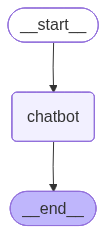

In [5]:
graph = graph_builder.compile()
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [6]:
while True:
    user_input = input("User: ")
    if user_input.lower() in ["quit", "exit", "q"]:
        print("Goodbye!")
        break
    for event in graph.stream({"messages": [("user", user_input)]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)

Assistant: Hello! 👋 How can I assist you today?
Assistant: **Finding a job can feel like a full‑time job in itself, but if you break it into a few simple, repeatable steps you’ll make the process feel quick, manageable, and even a little fun.**

---

## 1. Clarify *What* You’re Looking For  
| Why it matters | How to do it |
|-----------------|--------------|
| **Reduces wasted time** | Write a one‑sentence “career goal” (e.g., “I’m looking for a mid‑level marketing analyst role in a tech company that values data-driven decision making.”) |
| **Shows recruiters you’re focused** | List the top 3–5 job titles, industries, and company sizes that excite you. |
| **Helps you tailor your materials** | Keep this list handy; it’ll guide your resume, cover letter, and networking conversations. |

---

## 2. Polish Your “Toolkit”  
| Item | Quick‑Fix Checklist |
|------|---------------------|
| **Resume** | • 1‑page (or 2 if you have >10 years). <br>• Use bullet points that start with action ver